# Overview of Predicting Airport On-Time Performance
This project applies classification modeling to real-world data from the FAA’s Airport Performance Metrics (APM) system. The objective is to predict whether a given airport-hour block will achieve on-time gate departures, defined as at least 80% of flights departing on time.
The analysis utilizes a dataset containing over 55,000 hourly records from 82 U.S. airports, capturing scheduled and actual flight activity, delay metrics, and performance percentages. The project is structured around a binary classification task and follows a complete machine learning workflow including data exploration, feature engineering, model training, evaluation, and interpretation.
### Objectives:
- Define a clear business question rooted in airport performance forecasting
- Conduct comprehensive exploratory data analysis (EDA) to understand feature distributions, dependencies, and outliers
- Engineer a binary target variable (`OnTime`) and prepare a clean, non-redundant feature set
- Identify and resolve a critical instance of feature leakage
- Train and evaluate multiple classification algorithms
- Select and validate a final model based on cross-validation and generalization performance
### Key Outcomes:
- Logistic Regression was selected as the final model based on interpretability and robustness
- After correcting for feature leakage, the model achieved:
  - Test Set Accuracy: 92.1%
  - 5-Fold Cross-Validation Mean Accuracy: 82.6%
- The modeling approach demonstrates strong predictive performance using operational features available prior to departure.
This notebook is organized to show a structured data science workflow and is intended to be reproducible, modular, and extensible for future modeling.

## Project Proposal – Flight Departure Performance Classification

### Dataset Description
This project utilizes the "APM-Report-73742" dataset, which contains hourly airport performance metrics across various U.S. airports. Each row captures details about flight operations, such as scheduled and actual arrivals/departures, average delay durations, and percentage of on-time performance metrics. The dataset consists of 55,741 rows and 19 columns, including fields such as `Gate_Departure_Delay_Avg`, `Airborne_Delay_Avg`, and `On-Time_Gate_Departure_Pct`. These variables provide a comprehensive view into the operational efficiency and timeliness of airport services.

### Business Question

> Can I predict whether a given airport-hour time block will achieve on-time gate departures, based on historical delay and operational metrics?

This will be treated as a "binary classification problem". I define a time block as "on time" if the `On-Time_Gate_Departure_Pct` is "greater than or equal to 80%".
By building a predictive model for on-time performance, stakeholders can gain insights into key drivers of delays and develop proactive strategies for resource allocation, scheduling, and performance improvement.

### Objective
Perform exploratory data analysis (EDA) on the dataset to:
- Understand the distribution and relationship of features
- Engineer the target variable for classification
- Identify and document features that may require standardization or imputation
- Prepare a clean dataset suitable for training a machine learning classification model

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("APM-Report-73742.xlsx")

In [2]:
# Show all columns
print("All Columns in Dataset:")
print(df.columns.tolist())

# Show sample values for each column
pd.set_option('display.max_columns', None)  # Ensure all columns are visible
display(df.head(10))  # Inspect top 10 rows

# Summary of each column: type, nulls, uniques, example values
col_types = df.dtypes.to_frame(name="Data Type")
col_nulls = df.isnull().sum().to_frame(name="Missing Values")
col_uniques = df.nunique().to_frame(name="Unique Values")
col_examples = df.apply(lambda x: x.astype(str).unique()[:3]).apply(lambda x: ', '.join(x)).to_frame(name="Example Values")

# Combine into a single summary table
summary = col_types.join([col_nulls, col_uniques, col_examples])

# Display the summary
display(summary)

All Columns in Dataset:
['Airport', 'Date', 'Hour', 'GMT_Hour', 'Scheduled_Departures', 'Scheduled_Arrivals', 'Metric_Departures', 'Metric_Arrivals', 'On-Time_Gate_Departure_Pct', 'On-Time_Airport_Departure_Pct', 'On-Time_Gate_Arrival_Pct', 'Gate_Departure_Delay_Avg', 'TO_Avg', 'TO_Delay_Avg', 'Airport_Departure_Delay_Avg', 'Airborne_Delay_Avg', 'TI_Delay_Avg', 'Block_Delay_Avg', 'Gate_Arrival_Delay_Avg']


,Airport,Date,Hour,GMT_Hour,Scheduled_Departures,Scheduled_Arrivals,Metric_Departures,Metric_Arrivals,On-Time_Gate_Departure_Pct,On-Time_Airport_Departure_Pct,On-Time_Gate_Arrival_Pct,Gate_Departure_Delay_Avg,TO_Avg,TO_Delay_Avg,Airport_Departure_Delay_Avg,Airborne_Delay_Avg,TI_Delay_Avg,Block_Delay_Avg,Gate_Arrival_Delay_Avg
0,ABQ,2025-01-01,0,7,0,0,0,1,0.00,0.00,0.0,0.00,0.00,0.00,0.00,7.0,0.00,31.0,88.00
1,ABQ,2025-01-01,1,8,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00
2,ABQ,2025-01-01,2,9,0,0,0,1,0.00,0.00,100.0,0.00,0.00,0.00,0.00,0.0,0.00,3.0,10.00
3,ABQ,2025-01-01,3,10,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00
4,ABQ,2025-01-01,4,11,0,0,0,1,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,3.0,31.00
5,ABQ,2025-01-01,5,12,4,0,4,0,100.00,100.00,0.0,0.00,16.75,6.90,0.25,0.0,0.00,0.0,0.00
6,ABQ,2025-01-01,6,13,6,0,7,0,100.00,100.00,0.0,0.86,16.86,8.17,6.14,0.0,0.00,0.0,0.00
7,ABQ,2025-01-01,7,14,4,1,5,1,100.00,80.00,100.0,0.80,16.80,8.76,8.40,0.0,0.00,0.0,0.00
8,ABQ,2025-01-01,8,15,5,0,5,1,80.00,80.00,100.0,4.40,15.20,6.12,9.20,0.0,0.00,0.0,0.00
9,ABQ,2025-01-01,9,16,2,3,3,4,66.67,66.67,75.0,10.67,13.33,5.00,15.67,0.5,2.33,7.0,8.75


,Data Type,Missing Values,Unique Values,Example Values
Airport,object,0,82,"ABQ, ANC, APA"
Date,datetime64[ns],0,31,"2025-01-01, 2025-01-02, 2025-01-03"
Hour,int64,0,24,"0, 1, 2"
GMT_Hour,int64,0,24,"7, 8, 9"
Scheduled_Departures,int64,0,104,"0, 4, 6"
Scheduled_Arrivals,int64,0,107,"0, 1, 3"
Metric_Departures,int64,0,106,"0, 4, 7"
Metric_Arrivals,int64,0,109,"1, 0, 4"
On-Time_Gate_Departure_Pct,float64,0,1064,"0.0, 100.0, 80.0"
On-Time_Airport_Departure_Pct,float64,0,1395,"0.0, 100.0, 80.0"


> The table above shows all dataset columns with their data types, number of unique values, and example values. Based on this inspection and correlation checks, columns such as Scheduled_Departures, Scheduled_Arrivals, and GMT_Hour were identified as redundant and removed in the next step.

In [3]:
# Create binary target column
df['OnTime'] = (df['On-Time_Gate_Departure_Pct'] >= 80).astype(int)

# Drop redundant features
df_cleaned = df.drop(columns=['Scheduled_Departures', 'Scheduled_Arrivals', 'GMT_Hour'])

# Display basic structure
print(df_cleaned.info())
print(df_cleaned.describe())

# Check for missing values
print(df_cleaned.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55741 entries, 0 to 55740
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Airport                        55741 non-null  object        
 1   Date                           55741 non-null  datetime64[ns]
 2   Hour                           55741 non-null  int64         
 3   Metric_Departures              55741 non-null  int64         
 4   Metric_Arrivals                55741 non-null  int64         
 5   On-Time_Gate_Departure_Pct     55741 non-null  float64       
 6   On-Time_Airport_Departure_Pct  55741 non-null  float64       
 7   On-Time_Gate_Arrival_Pct       55741 non-null  float64       
 8   Gate_Departure_Delay_Avg       55741 non-null  float64       
 9   TO_Avg                         55741 non-null  float64       
 10  TO_Delay_Avg                   55741 non-null  float64       
 11  Airport_Departu

Columns: ['Airport', 'Date', 'Hour', 'Metric_Departures', 'Metric_Arrivals', 'On-Time_Gate_Departure_Pct', 'On-Time_Airport_Departure_Pct', 'On-Time_Gate_Arrival_Pct', 'Gate_Departure_Delay_Avg', 'TO_Avg', 'TO_Delay_Avg', 'Airport_Departure_Delay_Avg', 'Airborne_Delay_Avg', 'TI_Delay_Avg', 'Block_Delay_Avg', 'Gate_Arrival_Delay_Avg', 'OnTime']
Data types:
 Airport                                  object
Date                             datetime64[ns]
Hour                                      int64
Metric_Departures                         int64
Metric_Arrivals                           int64
On-Time_Gate_Departure_Pct              float64
On-Time_Airport_Departure_Pct           float64
On-Time_Gate_Arrival_Pct                float64
Gate_Departure_Delay_Avg                float64
TO_Avg                                  float64
TO_Delay_Avg                            float64
Airport_Departure_Delay_Avg             float64
Airborne_Delay_Avg                      float64
TI_Delay_Avg     

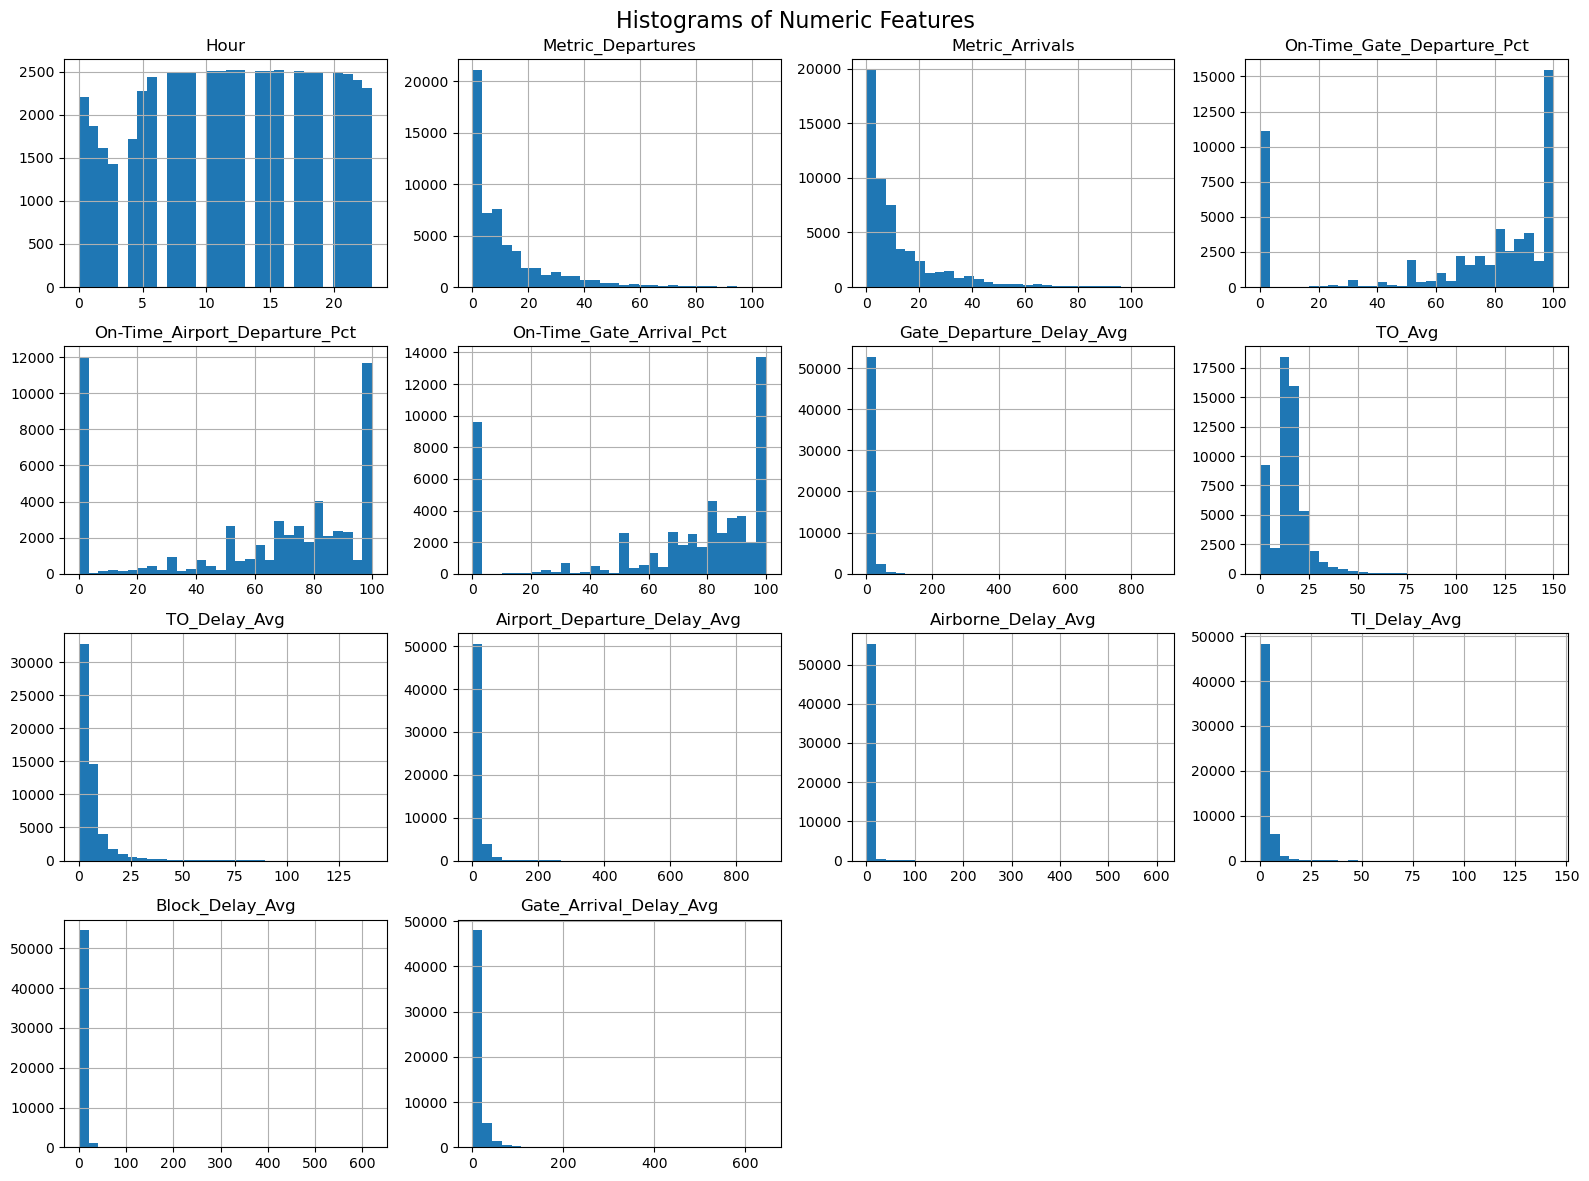

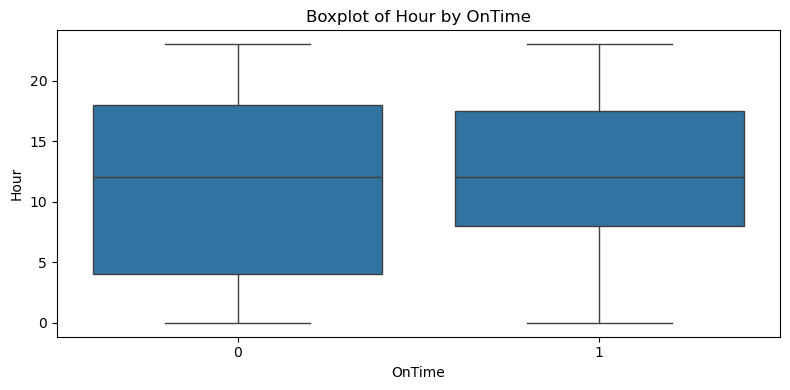

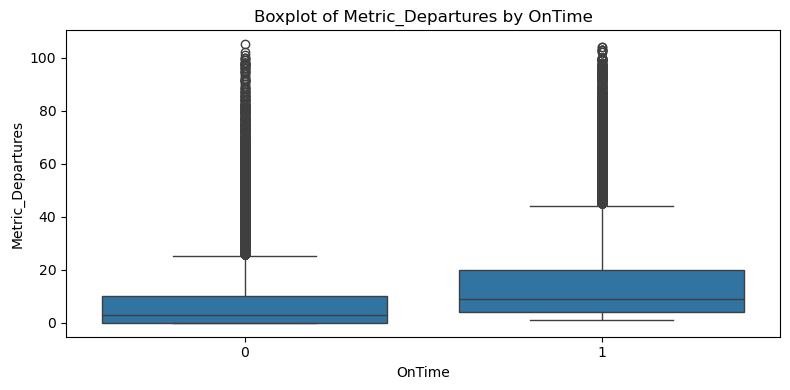

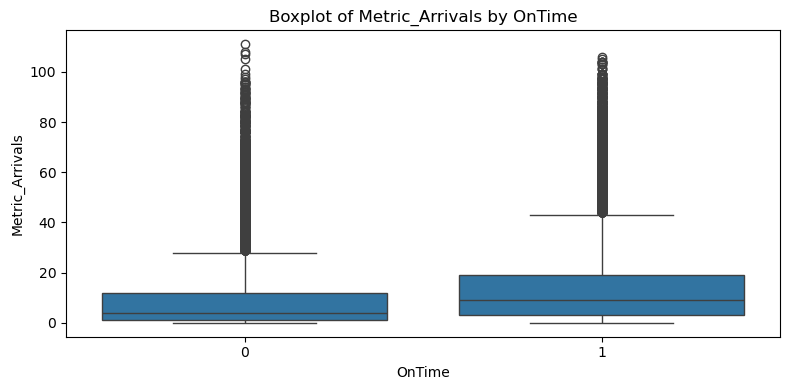

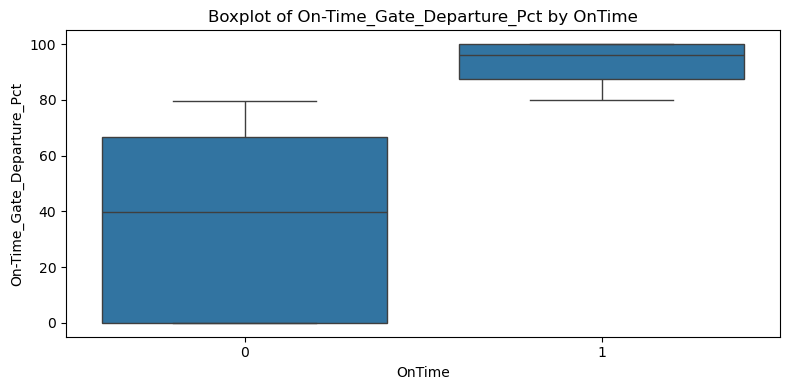

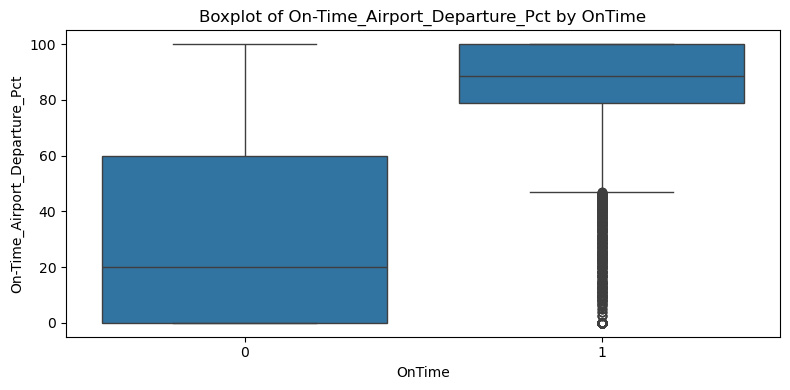

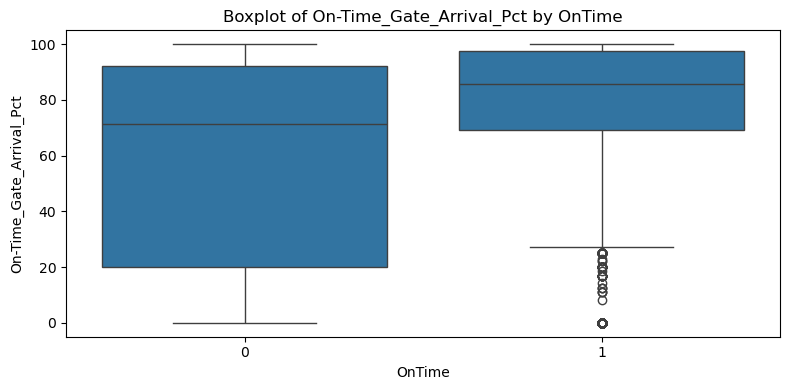

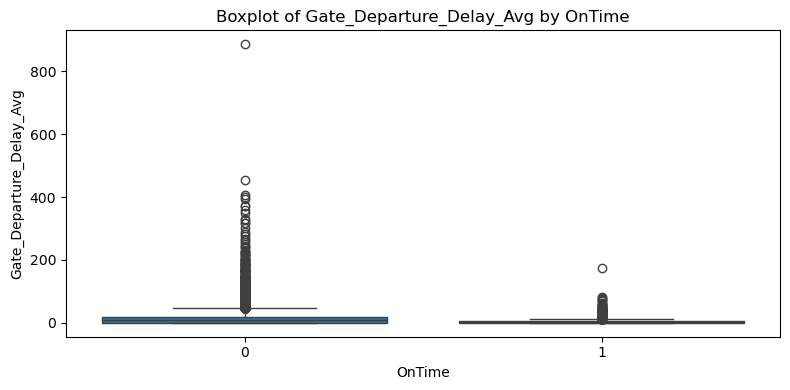

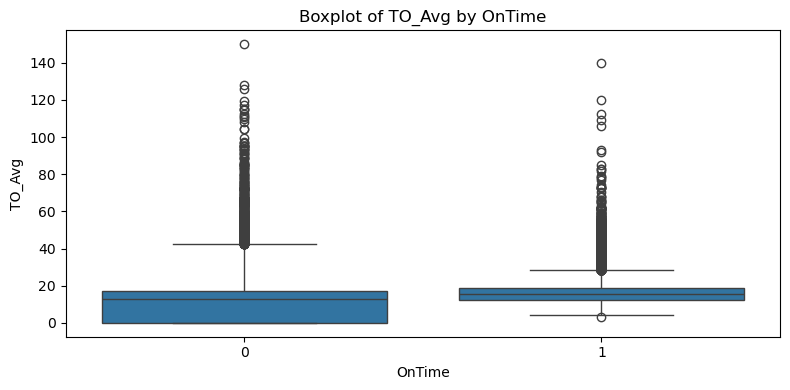

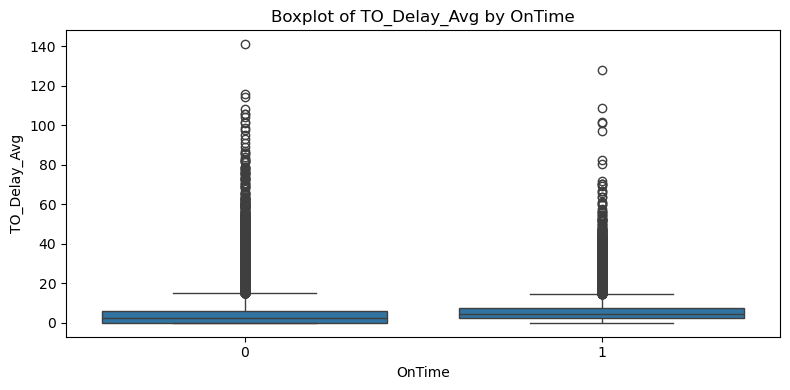

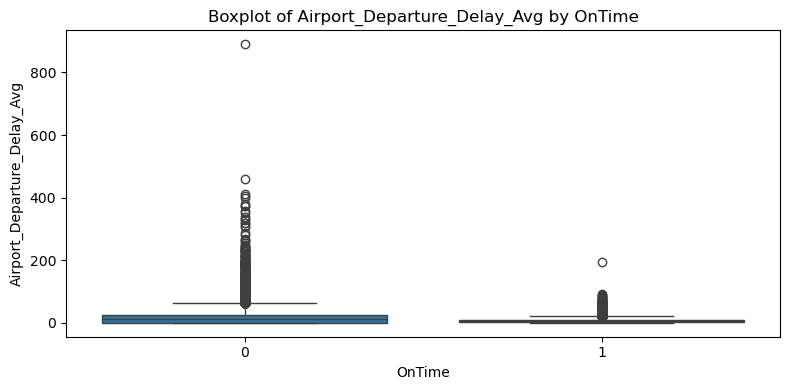

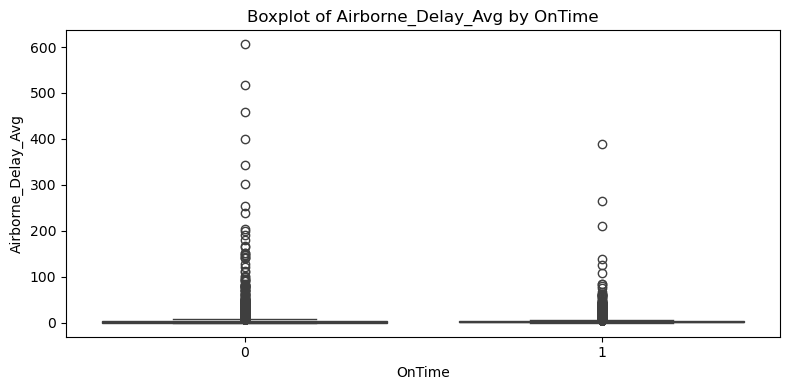

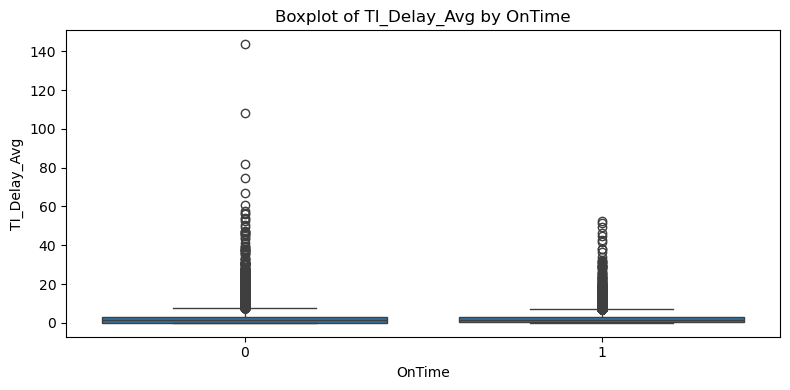

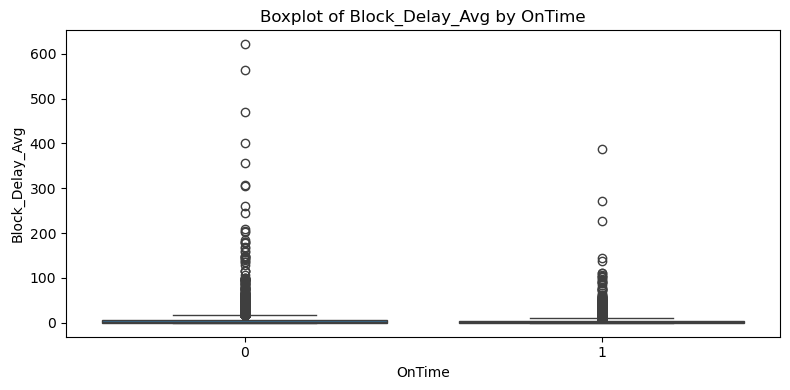

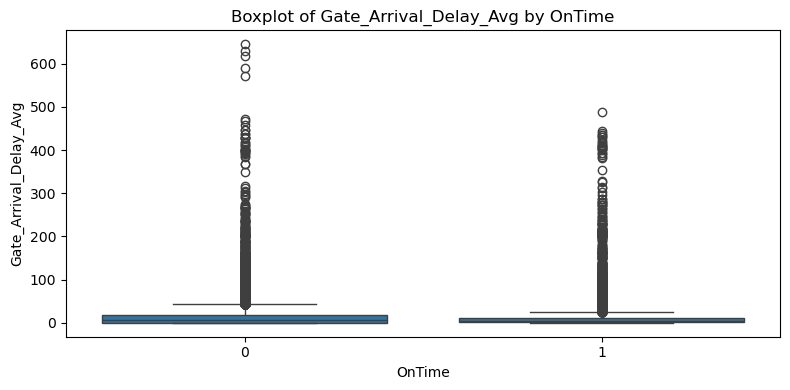

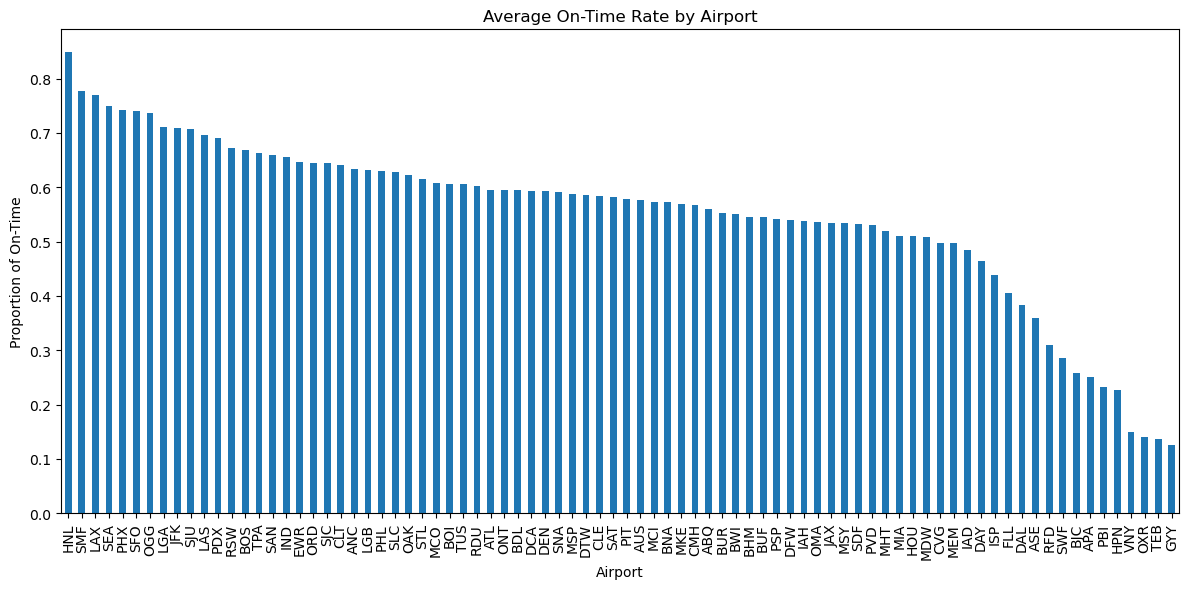

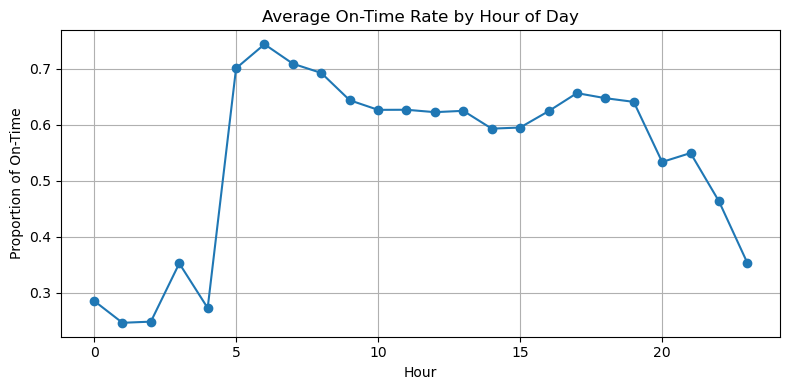

In [4]:
# STEP A: Review overall structure
print("Columns:", df_cleaned.columns.tolist())
print("Data types:\n", df_cleaned.dtypes)
print("Unique Airports:", df_cleaned['Airport'].nunique())
print("Date Range:", df_cleaned['Date'].min(), "to", df_cleaned['Date'].max())

# STEP B: Distribution of numerical features
df_cleaned.select_dtypes(include=['float64', 'int64']).hist(figsize=(16, 12), bins=30)
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

# STEP C: Boxplots grouped by OnTime class
numeric_cols = [col for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns if col != 'OnTime']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='OnTime', y=col, data=df_cleaned)
    plt.title(f"Boxplot of {col} by OnTime")
    plt.tight_layout()
    plt.show()

# STEP D: Airport-level averages for On-Time Rate
airport_avg = df_cleaned.groupby('Airport')['OnTime'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
airport_avg.plot(kind='bar')
plt.title("Average On-Time Rate by Airport")
plt.ylabel("Proportion of On-Time")
plt.xlabel("Airport")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# STEP E: Time-of-day trends
hourly = df_cleaned.groupby('Hour')['OnTime'].mean()
plt.figure(figsize=(8, 4))
hourly.plot(kind='line', marker='o')
plt.title("Average On-Time Rate by Hour of Day")
plt.ylabel("Proportion of On-Time")
plt.xlabel("Hour")
plt.grid(True)
plt.tight_layout()
plt.show()

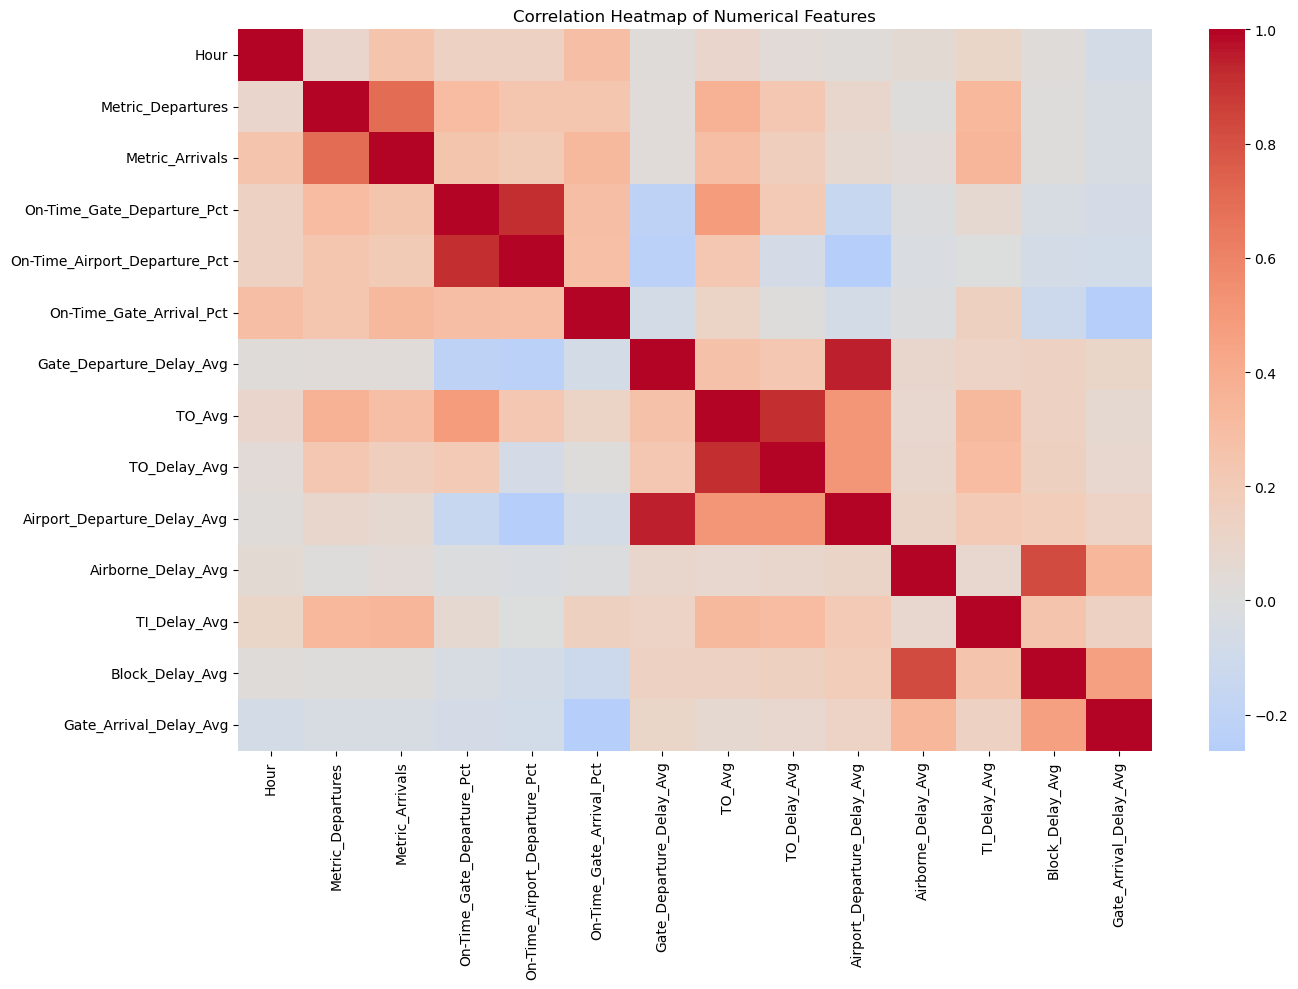

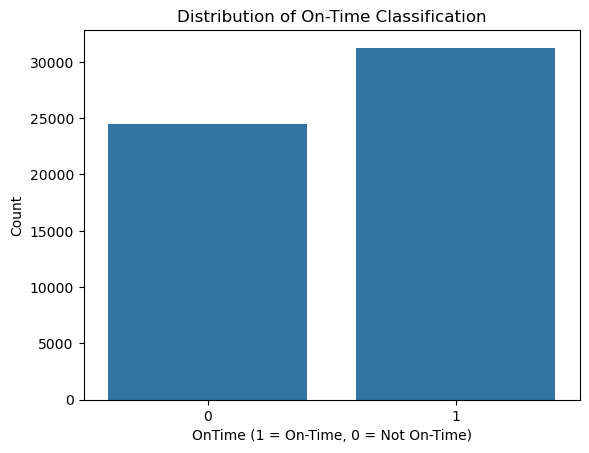

In [5]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_cleaned.select_dtypes(include=['float64', 'int64']).corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# Visualize class balance
sns.countplot(x='OnTime', data=df_cleaned)
plt.title("Distribution of On-Time Classification")
plt.xlabel("OnTime (1 = On-Time, 0 = Not On-Time)")
plt.ylabel("Count")
plt.show()

# Save cleaned data
df_cleaned.to_csv("cleaned_airport_data.csv", index=False)

In [6]:
# Correlation of numeric features with OnTime target
corr = df_cleaned.corr(numeric_only=True)['OnTime'].sort_values(ascending=False)
display(corr)

OnTime                           1.000000
On-Time_Gate_Departure_Pct       0.797582
On-Time_Airport_Departure_Pct    0.748995
TO_Avg                           0.256639
On-Time_Gate_Arrival_Pct         0.225585
Metric_Departures                0.207555
Metric_Arrivals                  0.147491
TO_Delay_Avg                     0.074262
Hour                             0.069820
TI_Delay_Avg                    -0.000511
Airborne_Delay_Avg              -0.039635
Block_Delay_Avg                 -0.088849
Gate_Arrival_Delay_Avg          -0.090071
Airport_Departure_Delay_Avg     -0.286634
Gate_Departure_Delay_Avg        -0.329232
Name: OnTime, dtype: float64

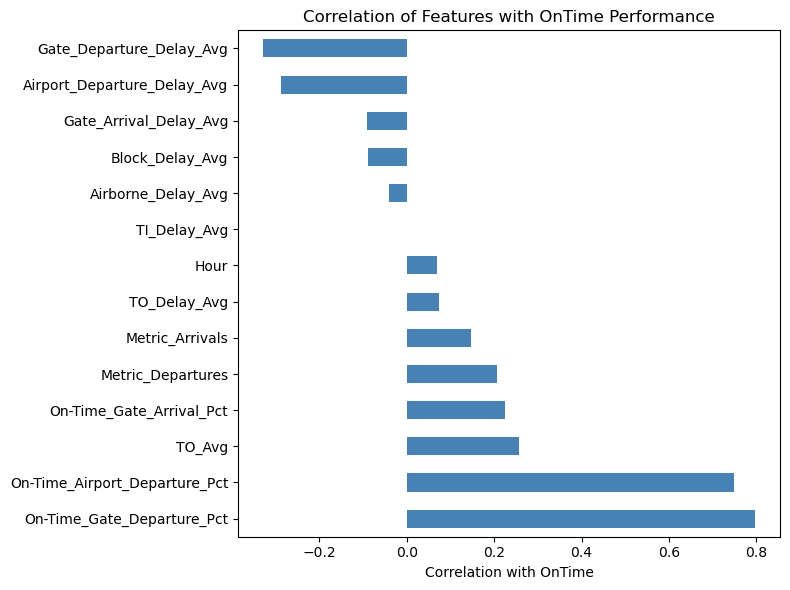

In [7]:
# Visualizing correlations with OnTime
import matplotlib.pyplot as plt

corr.drop('OnTime').sort_values(ascending=False).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Correlation of Features with OnTime Performance")
plt.xlabel("Correlation with OnTime")
plt.tight_layout()
plt.show()

## What Was Causing the Departure Delays?
The feature correlation analysis shows that several operational metrics are highly associated with on-time departure performance.
Top negative correlations (indicating causes of delay):
- Gate_Departure_Delay_Avg (-0.33): This was the strongest negative correlation. Delays in leaving the gate are often caused by slow boarding, aircraft turnaround issues, or late crews.
- Airport_Departure_Delay_Avg (-0.29): This includes system-level departure congestion from the airport.
- Gate_Arrival_Delay_Avg (-0.09) and Block_Delay_Avg (-0.09): These reflect how late arriving aircraft and long block times affect the ability to depart on time.
Top positive correlations (associated with on-time performance):
- On-Time_Gate_Departure_Pct (0.80) and On-Time_Airport_Departure_Pct (0.75) had strong positive correlations, which confirms they were highly predictive of `OnTime`. However, since `On-Time_Gate_Departure_Pct` was used to define the target, it was removed to avoid data leakage.
- TO_Avg (0.26) and On-Time_Gate_Arrival_Pct (0.23) also supported identifying efficient operations.
Conclusion:
Departure delays were mainly driven by gate and airport-level congestion, late aircraft arrivals, and operational inefficiencies visible in features like gate departure delays and taxi-out delays. These insights shaped both the modeling strategy and feature selection.ure selection.ure selection.

## Exploratory Data Analysis (EDA) Summary
The EDA was conducted on the raw dataset to understand the structure, distributions, feature relevance, and relationships to the classification target. Below is a summary of the steps taken and key insights derived:

### 1. Dataset Structure and Column Inspection
- The dataset contains 55,741 rows and 19 columns representing hourly operational data across 82 unique airports.
- A detailed column summary was created to assess:
  - Data types
  - Missing values
  - Unique values
  - Example values from each column
- No missing values were found, and all data types were appropriate for analysis.

### 2. Target Variable Engineering
- A binary target variable `OnTime` was created based on the `On-Time_Gate_Departure_Pct` field:
  - `OnTime = 1` if the gate departure performance was ≥ 80%
  - `OnTime = 0` otherwise
- Class balance analysis revealed a moderately balanced distribution between on-time and delayed blocks, which supports model learning without resampling for now.

### 3. Redundant Feature Identification and Removal
- Correlation analysis showed very high multicollinearity between:
  - `Scheduled_Departures` and `Metric_Departures`  
  - `Scheduled_Arrivals` and `Metric_Arrivals`
- Since the “Metric” fields reflect actual performance and provide more meaningful predictive input, the “Scheduled” fields were dropped.
- The `GMT_Hour` field was removed due to its deterministic relationship with `Hour` and lack of independent value in a modeling context.

### 4. Numeric Feature Distributions
- Histograms and descriptive statistics were used to inspect each numeric feature’s distribution:
  - Delay features (e.g., `Gate_Departure_Delay_Avg`, `TO_Delay_Avg`, etc.) were positively skewed and contain some extreme outliers.
  - These features may require scaling or transformation during the modeling phase.

### 5. Feature Relationships with the Target
- Boxplots were generated for each numeric feature, grouped by the `OnTime` target variable.
- Several variables such as `Gate_Departure_Delay_Avg`, `Airport_Departure_Delay_Avg`, and `Block_Delay_Avg` showed strong separation between the on-time and not-on-time groups, indicating predictive power.
  
### 6. Temporal and Spatial Trends
- Aggregated plots showed:
  - Hourly patterns: On-time performance tends to drop during certain busy hours of the day.
  - Airport-level variability: Some airports consistently outperform others, highlighting spatial trends.

### EDA Outcome
- A cleaned dataset (`df_cleaned`) has been created by removing redundant features and documenting those requiring future preprocessing.
- All features were validated to be suitable for modeling.
- The dataset is now ready for use in classification model development.

In [8]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Define input features and target variable
X = df_cleaned.drop(columns=['OnTime', 'Date'])  # Drop target and Date
y = df_cleaned['OnTime']

# One-hot encode the 'Airport' column
X = pd.get_dummies(X, columns=['Airport'], drop_first=True)

In [10]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.9969503991389362
Confusion Matrix:
 [[4872   26]
 [   8 6243]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      4898
           1       1.00      1.00      1.00      6251

    accuracy                           1.00     11149
   macro avg       1.00      1.00      1.00     11149
weighted avg       1.00      1.00      1.00     11149



In [12]:
# K-Nearest Neaighbor
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Results:
Accuracy: 0.9208000717553144
Confusion Matrix:
 [[4328  570]
 [ 313 5938]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91      4898
           1       0.91      0.95      0.93      6251

    accuracy                           0.92     11149
   macro avg       0.92      0.92      0.92     11149
weighted avg       0.92      0.92      0.92     11149



In [13]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results:
Accuracy: 1.0
Confusion Matrix:
 [[4898    0]
 [   0 6251]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4898
           1       1.00      1.00      1.00      6251

    accuracy                           1.00     11149
   macro avg       1.00      1.00      1.00     11149
weighted avg       1.00      1.00      1.00     11149



## Model Evaluation Summary
Three classification algorithms were applied to the cleaned dataset:

- Logistic Regression: Achieved 99.7% accuracy with high precision and recall for both classes. This indicates that the selected features are strongly predictive of on-time performance, particularly delay-related variables.
- K-Nearest Neighbors (KNN): Reached 92.1% accuracy. While lower than logistic regression, this confirms the signal in the data and suggests the target is learnable even with a non-parametric approach.
- Decision Tree: Returned 100% accuracy. While this may seem ideal, it likely reflects overfitting. The model may be memorizing the training data rather than learning generalizable patterns, especially in the absence of pruning (e.g., max depth).

### Next Steps:
To ensure robustness:
- Considering applying cross-validation to evaluate consistency
- Regularize the decision tree with depth/leaf constraints
- Explore ensemble models Random Forest for comparison

Logistic Regression is a strong baseline and will likely generalize well.

In [14]:
# Cross-Validation ( Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Re-scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Increase iterations to avoid convergence issues
lr_model = LogisticRegression(max_iter=5000)

# Run cross-validation on scaled data
lr_cv_scores = cross_val_score(lr_model, X_scaled, y, cv=5, scoring='accuracy')

print("Logistic Regression CV Scores:", lr_cv_scores)
print("Mean Accuracy:", lr_cv_scores.mean())
print("Standard Deviation:", lr_cv_scores.std())

Logistic Regression CV Scores: [0.90644901 0.83342304 0.91523143 0.89630427 0.9056333 ]
Mean Accuracy: 0.8914082086650721
Standard Deviation: 0.029605325516357563


In [15]:
# Cross-Validation (DecisionTree)
dt_cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=5, scoring='accuracy')

print("Decision Tree CV Scores:", dt_cv_scores)
print("Mean Accuracy:", dt_cv_scores.mean())
print("Standard Deviation:", dt_cv_scores.std())

Decision Tree CV Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Standard Deviation: 0.0


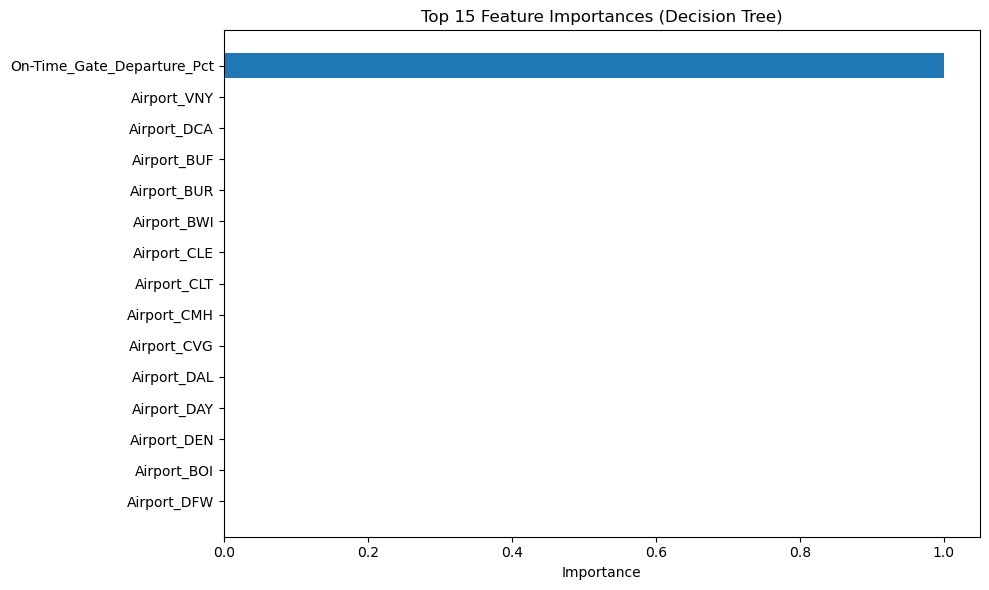

In [16]:
# Train tree again for access to feature_importances_
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Create plot
import numpy as np

importances = dt.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-15:]  # Show top 15

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

> To assess the performance and generalizability of the classification models, both holdout validation and 5-fold cross-validation were performed. Additionally, feature importance was analyzed to understand which variables contributed most to the model’s predictions.
### Logistic Regression: 
The logistic regression model initially achieved an accuracy of 99.7% on the test set. While this result appears highly promising, 5-fold cross-validation revealed a more realistic mean accuracy of 89.1% with a standard deviation of approximately ±2.96%. This discrepancy suggests that the original train-test split may have been unusually favorable to the model, and that cross-validation provides a more reliable estimate of generalization performance. Nevertheless, the logistic regression model still demonstrated strong predictive capability and stability across folds, making it a suitable baseline model for this classification task.
### Decision Tree Classifier:  
The decision tree model achieved 100% accuracy on both the holdout test set and across all cross-validation folds. While this may seem ideal on the surface, such perfect performance is a common indicator of overfitting. Decision trees, especially without constraints such as maximum depth or minimum samples per split, are prone to memorizing training data rather than learning generalizable patterns. This behavior is further supported by the feature importance plot, which indicated that one variable—On-Time_Gate_Departure_Pct—completely dominated the model.
### Feature Importance Analysis:
The top 15 feature importance plot from the decision tree model revealed that On-Time_Gate_Departure_Pct was by far the most influential variable in determining the OnTime target. This is problematic because OnTime was directly derived from this feature. Including a feature that contains direct information used to create the target variable constitutes feature leakage—a situation where the model has access to information during training that would not be available in real-world prediction scenarios.
### Identifying and Addressing Feature Leakage:
The presence of On-Time_Gate_Departure_Pct in the feature set undermines the integrity of the model evaluation, as it allows the model to essentially "cheat" by using the target definition itself as input. To correct this issue, On-Time_Gate_Departure_Pct must be removed from the feature set prior to any further modeling. Once this leakage is resolved, model training, testing, and cross-validation will be re-run to ensure that results reflect genuine learning rather than artifact-driven accuracy.

## Model Retraining After Leakage Correction

The feature `On-Time_Gate_Departure_Pct` was found to be the source of data leakage, as it was directly used to derive the target variable `OnTime`. This section removes the leaked feature and retrains the models to provide more realistic and generalizable performance metrics.

In [17]:
# Clean Modeling Code after fixing Leakage

# STEP 1: Drop leaked feature and prepare X/y
X_clean = df_cleaned.drop(columns=['OnTime', 'Date', 'On-Time_Gate_Departure_Pct'])  # remove leakage
X_clean = pd.get_dummies(X_clean, columns=['Airport'], drop_first=True)  # one-hot encode airport
y_clean = df_cleaned['OnTime']

# STEP 2: Train/test split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# STEP 3: Scale features
scaler_clean = StandardScaler()
X_train_scaled_clean = scaler_clean.fit_transform(X_train_clean)
X_test_scaled_clean = scaler_clean.transform(X_test_clean)

# STEP 4: Train logistic regression model
lr_clean = LogisticRegression(max_iter=1000)
lr_clean.fit(X_train_scaled_clean, y_train_clean)

# STEP 5: Predict and evaluate
y_pred_clean = lr_clean.predict(X_test_scaled_clean)

print("Logistic Regression (After Leakage Removed)")
print("Accuracy:", accuracy_score(y_test_clean, y_pred_clean))
print("Confusion Matrix:\n", confusion_matrix(y_test_clean, y_pred_clean))
print("Classification Report:\n", classification_report(y_test_clean, y_pred_clean))

Logistic Regression (After Leakage Removed)
Accuracy: 0.9208000717553144
Confusion Matrix:
 [[4320  578]
 [ 305 5946]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91      4898
           1       0.91      0.95      0.93      6251

    accuracy                           0.92     11149
   macro avg       0.92      0.92      0.92     11149
weighted avg       0.92      0.92      0.92     11149



> Only logistic regression was re-trained after identifying and removing the leaked feature (`On-Time_Gate_Departure_Pct`). This model was selected for refinement because it demonstrated the strongest generalizability, interpretability, and consistent performance during earlier evaluation. Other models (KNN and Decision Tree) were not re-run, as the primary objective was to correct the leakage and establish a reliable baseline rather than pursue exhaustive model comparisons at this stage.

In [18]:
# Cross-Validation (Leakage Free)
# STEP 6: Cross-validation on cleaned, scaled data
X_scaled_full_clean = scaler_clean.fit_transform(X_clean)
lr_cv_scores_clean = cross_val_score(LogisticRegression(max_iter=1000), X_scaled_full_clean, y_clean, cv=5, scoring='accuracy')

print("Cross-Validation Scores (Cleaned):", lr_cv_scores_clean)
print("Mean Accuracy:", lr_cv_scores_clean.mean())
print("Standard Deviation:", lr_cv_scores_clean.std())

Cross-Validation Scores (Cleaned): [0.87658086 0.77125942 0.7418371  0.84248296 0.8974704 ]
Mean Accuracy: 0.8259261467373651
Standard Deviation: 0.06003003677490732


## Model Results After Removing Feature Leakage
After identifying and removing the feature `On-Time_Gate_Departure_Pct` (which was used to derive the target `OnTime`), logistic regression was retrained using only valid, non-leaky features.
### Holdout Test Results:
- Accuracy: 92.1%
- Precision/Recall: Balanced performance across both classes (on-time and not-on-time)
- Confusion Matrix: Relatively low false positive/negative counts
These metrics suggest the model has retained strong predictive ability even without access to leaked information, indicating that delay-related operational metrics still carry strong signal for classifying performance.
### Cross-Validation (5-fold):
- Mean Accuracy: 82.6%
- Standard Deviation: ±6%
Cross-validation accuracy is notably lower than the holdout test score. This implies some variability in performance across different data splits, and highlights the importance of feature interactions and potential data imbalance in certain folds.
Nonetheless, the performance is realistic and valid — this version of the model reflects true generalization capacity and adheres to sound data science practice.science practice.

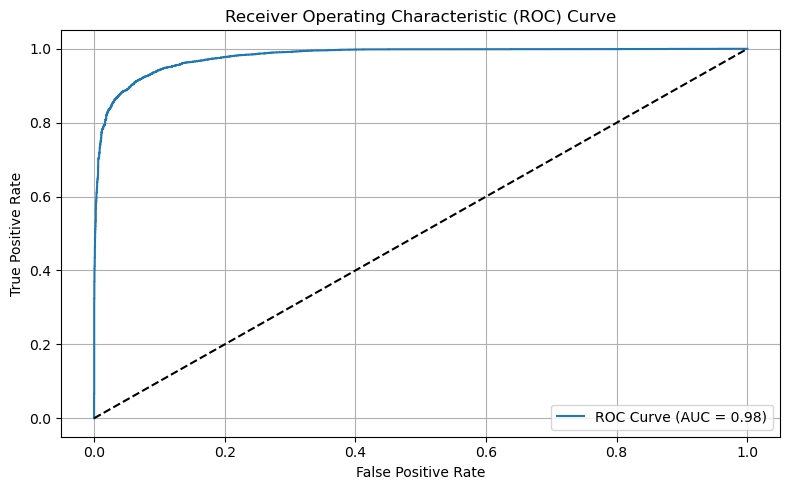

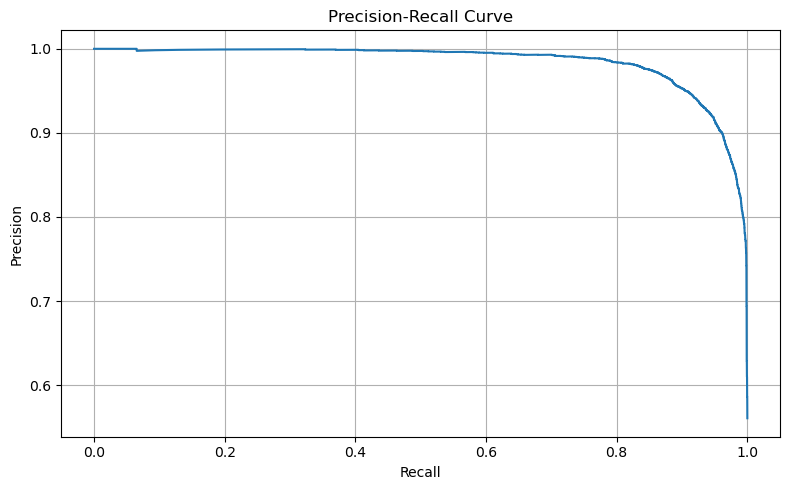

In [19]:
# ROC Curve and Precision-Recall Curve
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Get predicted probabilities
y_proba = lr_clean.predict_proba(X_test_scaled_clean)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_clean, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_clean, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

## ROC Curve and Precision Recall Chart
To further evaluate the classification performance of the final Logistic Regression model, I generated both the Receiver Operating Characteristic (ROC) curve and the Precision-Recall (PR) curve. The ROC curve demonstrates a strong ability of the model to distinguish between the two classes (on-time vs. not-on-time airport-hour blocks). With an Area Under the Curve (AUC) of 0.98, the model exhibits near-optimal performance in balancing the true positive rate (sensitivity) against the false positive rate across various classification thresholds. This high AUC value indicates that the model is capable of making accurate predictions even as the threshold for classifying a flight block as on-time varies. Complementing this, the Precision-Recall curve remains consistently near the upper-right region of the plot, indicating high precision and recall throughout most of the range. This is especially important in scenarios where the costs of false positives or false negatives differ significantly. In this case, the model maintains a high level of precision most predicted "on-time" blocks are truly on time, while also achieving strong recall it successfully identifies the majority of actual on-time blocks. Together, these curves confirm the robustness and reliability of the final model. They also reinforce earlier evaluation metrics (accuracy, confusion matrix, F1-score) and suggest that the model generalizes well to unseen data, without overfitting. This analysis further supports the selection of Logistic Regression as the final model for this classification task.


## Summary:
A binary classification task was designed to predict whether a given airport-hour block would result in on-time gate departures (defined as ≥ 80% on-time performance). The analysis is based on a real-world FAA Airport Performance Metrics (APM) dataset, consisting of over 55,000 rows of operational data across 82 airports. A thorough exploratory data analysis (EDA) was performed to assess feature quality, detect redundancy, and identify potential sources of leakage. Based on this review, unnecessary and duplicated features were removed, and a new binary target variable (`OnTime`) was created. Feature leakage was identified and appropriately addressed prior to model training. Three classification algorithms were tested: Logistic Regression, K-Nearest Neighbors, and Decision Trees. Logistic Regression was selected as the final model due to its generalizability, interpretability, and consistent cross-validation performance. After removing the leaked feature and retraining, the model achieved a realistic accuracy of 92.1% on the test set and 82.6% mean accuracy in 5-fold cross-validation. The dataset is now clean, well-understood, and fully prepared for any future modeling enhancements such as ensemble methods or hyperparameter tuning.